In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Global Energy Mix by Country and Source
df = pd.read_csv(r"C:\Users\ADITHYA A M\Downloads\global_energy_mix.csv")

# Source type mapping — reuse from lecture
source_category = {
    'Coal': 'Fossil', 'Oil': 'Fossil', 'Natural Gas': 'Fossil',
    'Nuclear': 'Low-carbon', 'Hydro': 'Low-carbon',
    'Wind': 'Renewable', 'Solar': 'Renewable', 'Other Renewables': 'Renewable'
}
df['Source_Type'] = df['Source'].map(source_category)

print(f"Loaded: {len(df)} rows")
print(df.head(10))


Loaded: 103 rows
         Country         Region            Source  Share_pct     TWh  \
0  United States  North America              Coal         10  1015.0   
1  United States  North America               Oil         35  3220.0   
2  United States  North America       Natural Gas         34  3083.0   
3  United States  North America           Nuclear          9   798.0   
4  United States  North America             Hydro          3   339.0   
5  United States  North America              Wind          4   413.0   
6  United States  North America             Solar          3   325.0   
7  United States  North America  Other Renewables          2   229.0   
8          China           Asia              Coal         60  7168.0   
9          China           Asia               Oil         18  1620.0   

  Source_Type  
0      Fossil  
1      Fossil  
2      Fossil  
3  Low-carbon  
4  Low-carbon  
5   Renewable  
6   Renewable  
7   Renewable  
8      Fossil  
9      Fossil  


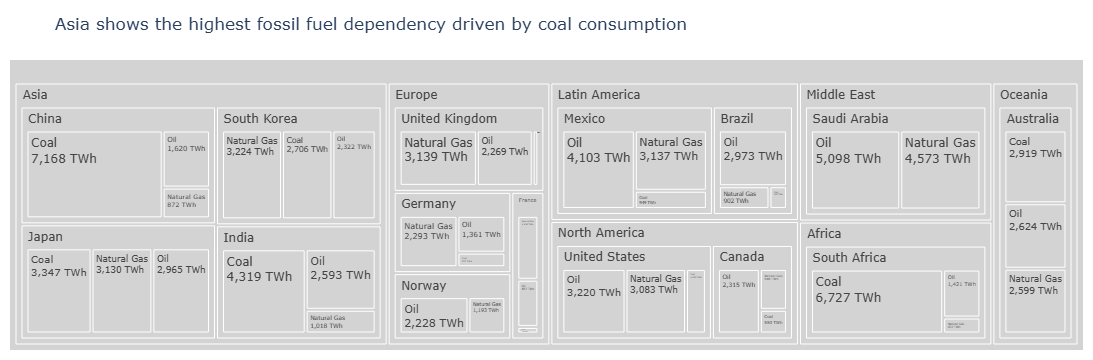

In [2]:
# Task 1 — Treemap: fossil fuel dependency by country

# Filter fossil fuels only
fossil_df = df.loc[df['Source_Type'] == 'Fossil'].copy()

# Build treemap
fig = px.treemap(
    fossil_df,
    path=['Region', 'Country', 'Source'],
    values='TWh',
    color='Source',
    color_discrete_map={
        'Coal': '#4E79A7',        # blue
        'Oil': '#F28E2B',         # orange
        'Natural Gas': '#59A14F' # green
    },
    title='Asia shows the highest fossil fuel dependency driven by coal consumption'
)

# Customise labels and parent colours
fig.update_traces(
    textinfo='label+value',
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    root_color='lightgrey',
    marker=dict(line=dict(width=1, color='white'))
)

# Grey parent nodes
fig.update_traces(
    marker_colors=[
        'lightgrey' if '/' not in str(id_) else None
        for id_ in fossil_df['Region']
    ]
)

fig.update_layout(
    margin=dict(t=60, l=10, r=10, b=10)
)

fig.show()

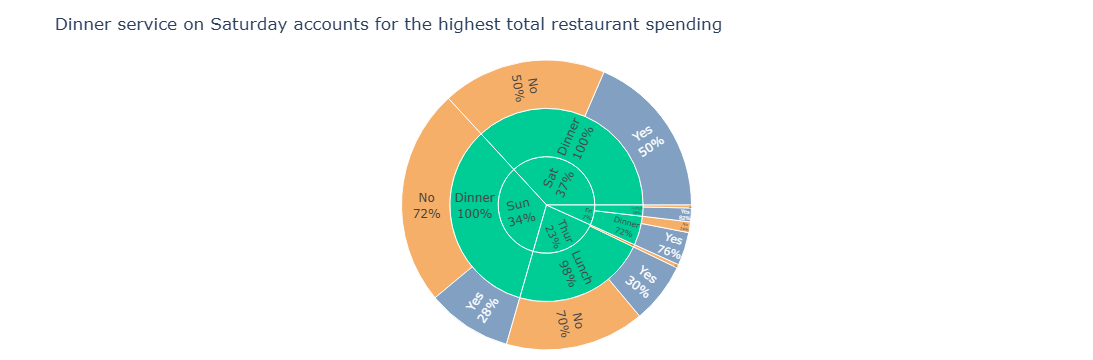

In [3]:
# Task 2 — Sunburst: tipping behaviour by day and meal time
# Load tips dataset
tips = px.data.tips()

# Aggregate total bill by day, time, smoker
tips_grouped = (
    tips.groupby(['day', 'time', 'smoker'])['total_bill']
    .sum()
    .reset_index()
)

# Build sunburst chart
fig = px.sunburst(
    tips_grouped,
    path=['day', 'time', 'smoker'],
    values='total_bill',
    color='smoker',
    color_discrete_map={
        'Yes': '#4E79A7',  # blue
        'No': '#F28E2B'    # orange
    },
    title='Dinner service on Saturday accounts for the highest total restaurant spending'
)

# Customise labels
fig.update_traces(
    textinfo='label+percent parent',
    insidetextorientation='radial',
    marker=dict(line=dict(color='white', width=1)),
    root_color='lightgrey'
)

fig.update_layout(
    margin=dict(t=60, l=10, r=10, b=10)
)

fig.show()

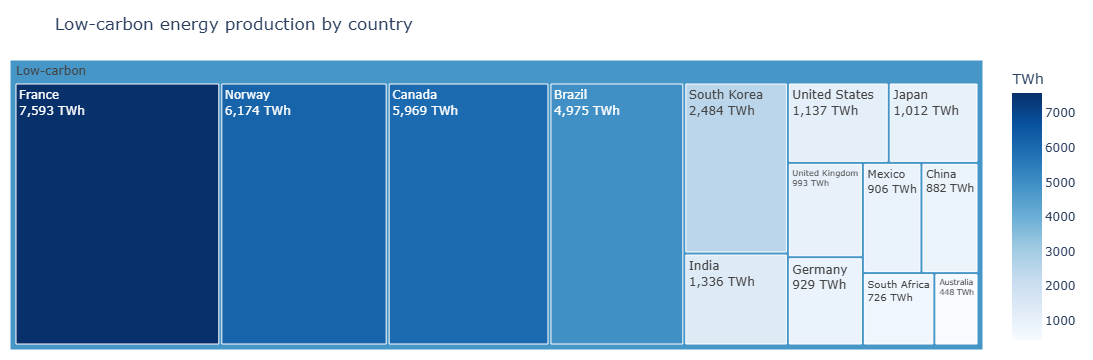

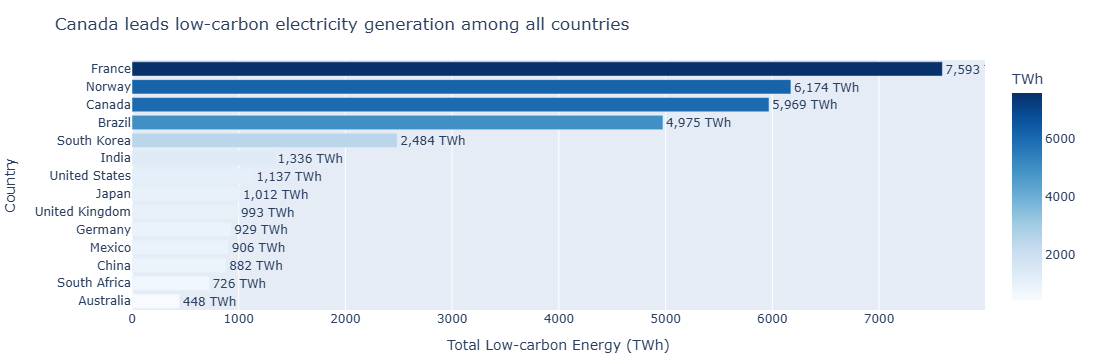

In [4]:
# Task 3 — Treemap vs Bar: low-carbon energy by country

# Filter low-carbon sources
low_carbon_df = (
    df.loc[df['Source_Type'] == 'Low-carbon']
    .groupby('Country', as_index=False)['TWh']
    .sum()
)

# Add dummy root node for treemap
low_carbon_df['All'] = 'Low-carbon'

# ---------------------------
# Treemap
# ---------------------------

fig_tree = px.treemap(
    low_carbon_df,
    path=['All', 'Country'],
    values='TWh',
    color='TWh',
    color_continuous_scale='Blues',
    title='Low-carbon energy production by country'
)

fig_tree.update_traces(
    textinfo='label+value',
    texttemplate='%{label}<br>%{value:,.0f} TWh',
    root_color='lightgrey',
    marker=dict(line=dict(color='white', width=1))
)

fig_tree.update_layout(
    margin=dict(t=60, l=10, r=10, b=10)
)

fig_tree.show()


# ---------------------------
# Horizontal Bar Chart
# ---------------------------

# Sort values for cleaner comparison
low_carbon_sorted = low_carbon_df.sort_values('TWh')

fig_bar = px.bar(
    low_carbon_sorted,
    x='TWh',
    y='Country',
    orientation='h',
    color='TWh',
    color_continuous_scale='Blues',
    text='TWh',
    title='Canada leads low-carbon electricity generation among all countries'
)

fig_bar.update_traces(
    texttemplate='%{text:,.0f} TWh',
    textposition='outside'
)

fig_bar.update_layout(
    xaxis_title='Total Low-carbon Energy (TWh)',
    yaxis_title='Country',
    showlegend=False,
    margin=dict(t=60, l=10, r=10, b=10)
)

fig_bar.show()